# Why Condition C's Combined Repair Fix Collapsed

This notebook is a **pure re-analysis** demo: it makes **no LLM calls** and **no new COMET scoring**. It reloads the already-computed results of three prior span-editing repair experiments on WMT25 `en-ru_RU` / `en-uk_UA` translations:

- **B / D / C1** (from `art_7Uc5PlFctjXi`)
- **C2** (from `art_K8koUmGFDlLN`)
- **Condition C** (from `art_6n9zJVKWXnio`)

and reconciles four open reviewer questions about why Condition C's combined repair fix collapsed:

1. **precision_tier_collapse_analysis** — does Condition C's certificate-rate collapse concentrate in checker cells with lower detection precision?
2. **checker_eligibility_restricted_analysis** — does the headline B/D/C1/C2/C ordering survive restriction to only the fully checker-eligible (language, category) cells?
3. **certificate_definition_by_category** — when a row's own corrupted category is itself an excluded checker cell, how is its certificate scored?
4. **normal_approx_bias_direction** — is the independence approximation for the variance of a difference of two positively-correlated ΔCOMET measurements conservative or anti-conservative?

This demo runs against a small curated subset of the original data (`mini_demo_data.json`) so it executes in seconds; the original script (`eval.py`) ran the identical logic against the full three artifacts.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru is not pre-installed on Colab -> always install
_pip('loguru==0.7.3')

# matplotlib is pre-installed on Colab -> only install locally, at Colab's exact version
if 'google.colab' not in sys.modules:
    _pip('matplotlib==3.10.0')


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python3.12 -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python3.12 -m pip install --upgrade pip


## Setup

Imports copied from the original `eval.py` as-is (`json`, `resource`, `sys`, `Path`, `loguru`), plus `matplotlib` for the results visualization added at the end of this notebook.

In [2]:
from __future__ import annotations

import json
import resource
import sys
from pathlib import Path

from loguru import logger

import matplotlib.pyplot as plt

logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")

# lang code (checker_validation) <-> language_pair (row metadata)
LANG_TO_PAIR = {"ru_RU": "en-ru_RU", "uk_UA": "en-uk_UA"}
# checker category (checker_validation) <-> row metadata_invariant_category
CAT_TO_INVARIANT = {
    "named_entity": "named_entity_swap",
    "number_unit_date": "number_unit_date_alteration",
    "negation_polarity": "negation_polarity_flip",
    "quantifier_scope": "quantifier_substitution",
}

## Data loading

`mini_demo_data.json` bundles a curated subset of the three source artifacts' files (`selected_rows.json`, `checker_validation.json`, `full_method_out.json`) under top-level keys `"d1"` (B/D/C1), `"d2"` (C2), and `"d3"` (Condition C) — mirroring the `D1`/`D2`/`D3` directories the original `eval.py` reads from disk. We try the GitHub-hosted copy first (for Colab), falling back to a local file (for local runs).

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-e9bf19-isolating-what-fixes-failed-span-editing/main/round-5/evaluation-1/demo/mini_demo_data.json"
import json, os

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f: return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print("Top-level keys:", list(data.keys()))
print("d1 injected-pool rows (subset):", len(data["d1"]["full_method_out"]["datasets"][1]["examples"]))
print("d2 injected-pool rows (subset):", len(data["d2"]["full_method_out"]["datasets"][1]["examples"]))
print("d3 injected-pool rows (subset):", len(data["d3"]["full_method_out"]["datasets"][1]["examples"]))

Top-level keys: ['d1', 'd2', 'd3']
d1 injected-pool rows (subset): 32
d2 injected-pool rows (subset): 32
d3 injected-pool rows (subset): 32


## Config

The original script has no scale-type knobs (no iterations/epochs/batch sizes) since it is a pure, deterministic re-analysis of already-computed JSON. The values below are the actual analysis constants `eval.py` hardcodes inline — pulled out here so they are visible/tunable in one place. They already run at full scale (they aren't reduced for this demo); what's reduced is the *data* (see `mini_demo_data.json`, ~4 rows per checker cell instead of the original ~30).

In [5]:
# Precision-tier split point used in precision_tier_collapse_analysis (original eval.py line ~159)
HIGH_PRECISION_THRESHOLD = 0.75

# Assumed correlations used in the normal_approx_bias_direction worked numeric examples (original eval.py line ~504)
ASSUMED_CORR_EXAMPLES = [0.0, 0.3, 0.6, 0.9]

# RAM safety cap in GB, matching the original script's RLIMIT_AS setrlimit call
RAM_LIMIT_GB = 6
resource.setrlimit(resource.RLIMIT_AS, (RAM_LIMIT_GB * 1024**3, RAM_LIMIT_GB * 1024**3))

## Small helpers

`mean` and `rate` are copied verbatim from `eval.py` — simple null-safe aggregate helpers used throughout every analysis below.

In [6]:
def mean(xs: list[float]) -> float | None:
    xs = [x for x in xs if x is not None]
    return round(sum(xs) / len(xs), 4) if xs else None


def rate(bools: list[bool]) -> float | None:
    bools = [b for b in bools if b is not None]
    return round(sum(1 for b in bools if b) / len(bools), 4) if bools else None

## 0. Cross-artifact identity checks

Before doing any computation, verify that the three dependency artifacts (B/D/C1, C2, Condition C) all selected the *exact same* rows for each of the three folds (`natural`, `injected-pool`, `injected-heldout`). This is a must-do sanity check: any downstream comparison across conditions is only meaningful if the conditions were run on identical row sets.

Logic is unchanged from `eval.py`'s `check_row_identity()` — only the three `load_json(D{1,2,3} / "selected_rows.json")` calls are replaced with the equivalent lookups into the loaded `data` dict.

In [7]:
def check_row_identity() -> dict:
    d1_rows = data["d1"]["selected_rows"]
    d2_rows = data["d2"]["selected_rows"]
    d3_rows = data["d3"]["selected_rows"]
    folds = ["natural_row_ids", "injected_pool_row_ids", "injected_heldout_row_ids"]
    result = {}
    for a, b, label in [(d1_rows, d2_rows, "bddc1_vs_c2"), (d2_rows, d3_rows, "c2_vs_c"), (d1_rows, d3_rows, "bddc1_vs_c")]:
        result[label] = {f: (a[f] == b[f]) for f in folds}
    result["all_identical"] = all(all(v.values()) for v in result.values())
    logger.info(f"Row-ID identity across all three artifacts: {result['all_identical']}")
    if not result["all_identical"]:
        logger.error(f"Row-ID mismatch detected: {result}")
    return result


identity = check_row_identity()

12:00:57|INFO   |Row-ID identity across all three artifacts: True


## 1. `precision_tier_collapse_analysis`

Splits the checker-eligible (language, category) cells into a **high-precision tier** and a **low-precision tier** (split point = `HIGH_PRECISION_THRESHOLD`), then recomputes Condition C's per-cell `certificate_rate` directly from raw per-row fields, and compares the mean certificate rate between the two tiers. A collapse concentrated in the low-precision tier is consistent with checker-noise-driven churn rather than a uniform cross-invariant regression.

`per_cell_certificate_from_raw_rows` is unchanged from the original. `precision_tier_collapse_analysis` is unchanged except the two `load_json(...)` file reads are replaced by `data["d1"]["checker_validation"]` and `data["d3"]["full_method_out"]`, and the hardcoded `0.75` tier-split threshold now reads from the `HIGH_PRECISION_THRESHOLD` config variable.

In [8]:
def per_cell_certificate_from_raw_rows(examples: list[dict], cert_field: str, passes_field: str) -> dict:
    """Recompute certificate_rate/mean-passes per (lang,category) cell directly
    from raw per-row fields. Needed because Condition C's own pre-aggregated
    injected_category_table reports certificate_rate=null for negation_polarity_flip
    (its 'n_attempted' convention there tracks span-based fix/regression semantics
    that do not apply to a deletion, NOT whether the checker certificate concept
    applies) even though metadata_c_certificate_achieved IS populated on every
    negation row. Verified: for the three categories where the pre-aggregated
    table DOES report a value, this recomputation matches it exactly (named_entity_swap,
    number_unit_date_alteration, quantifier_substitution -- all 6 language-pair
    cells bit-for-bit identical to injected_category_table), so this method is a
    validated superset, not a divergent re-derivation.
    """
    cells: dict[tuple[str, str], dict] = {}
    for e in examples:
        key = (e["metadata_language_pair"], e["metadata_invariant_category"])
        cells.setdefault(key, {"certs": [], "passes": []})
        cells[key]["certs"].append(e.get(cert_field))
        cells[key]["passes"].append(e.get(passes_field))
    out = {}
    for key, v in cells.items():
        out[key] = {
            "n_rows": len(v["certs"]),
            "certificate_rate": rate(v["certs"]),
            "mean_passes": mean(v["passes"]),
        }
    return out


def precision_tier_collapse_analysis() -> dict:
    validation = data["d1"]["checker_validation"]
    excluded = set(validation["excluded_cells"])
    per_cell_precision = validation["per_cell"]

    d3 = data["d3"]["full_method_out"]
    c_injected_examples = d3["datasets"][1]["examples"]
    c_cells_raw = per_cell_certificate_from_raw_rows(
        c_injected_examples, "metadata_c_certificate_achieved", "metadata_c_n_passes"
    )
    # sanity check against Condition C's own pre-aggregated table (the 3 non-negation
    # categories should match exactly; logged, not asserted, since a mismatch here
    # would itself be a reportable finding rather than a bug to crash on)
    agg_table = {
        (row["language_pair"], row["category"]): row for row in d3["metadata"]["metrics"]["injected_category_table"]
    }
    mismatches = []
    for key, row in agg_table.items():
        if row.get("certificate_rate") is None:
            continue
        recomputed = c_cells_raw.get(key, {}).get("certificate_rate")
        if recomputed is None or abs(recomputed - row["certificate_rate"]) > 1e-6:
            mismatches.append({"cell": list(key), "table": row["certificate_rate"], "recomputed": recomputed})
    if mismatches:
        logger.warning(f"Raw-row recomputation mismatches Condition C's own table (expected on this mini subset): {mismatches}")
    else:
        logger.info("Raw-row certificate recomputation matches Condition C's own injected_category_table exactly "
                     "for all non-negation cells.")

    usable_cells = []
    for cat_key, cat_info in per_cell_precision.items():
        lang, cat = cat_info["lang"], cat_info["category"]
        if f"{lang}|{cat}" in excluded:
            continue
        pair = LANG_TO_PAIR[lang]
        invariant = CAT_TO_INVARIANT[cat]
        c_cell = c_cells_raw.get((pair, invariant), {})
        usable_cells.append({
            "lang": lang,
            "category": cat,
            "checker_precision": cat_info["precision"],
            "checker_recall": cat_info["recall"],
            "certificate_rate_condition_c": c_cell.get("certificate_rate"),
            "mean_pass_count_condition_c": c_cell.get("mean_passes"),
            "n_rows": c_cell.get("n_rows"),
        })

    # Tier assignment per plan: high ~0.78-0.86, low ~0.575-0.65
    high_tier = [c for c in usable_cells if c["checker_precision"] >= HIGH_PRECISION_THRESHOLD]
    low_tier = [c for c in usable_cells if c["checker_precision"] < HIGH_PRECISION_THRESHOLD]

    high_certs = [c["certificate_rate_condition_c"] for c in high_tier]
    low_certs = [c["certificate_rate_condition_c"] for c in low_tier]
    high_passes = [c["mean_pass_count_condition_c"] for c in high_tier]
    low_passes = [c["mean_pass_count_condition_c"] for c in low_tier]

    high_mean_cert, low_mean_cert = mean(high_certs), mean(low_certs)
    high_mean_pass, low_mean_pass = mean(high_passes), mean(low_passes)

    n_usable = len(usable_cells)
    low_power = n_usable < 6
    if high_mean_cert is None or low_mean_cert is None:
        collapse_pattern = "indeterminate_too_few_cells"
    elif abs(high_mean_cert - low_mean_cert) < 0.05:
        collapse_pattern = "uniform_across_tiers"
    elif low_mean_cert < high_mean_cert:
        collapse_pattern = "concentrated_in_low_precision_tier"
    else:
        collapse_pattern = "concentrated_in_high_precision_tier"

    return {
        "usable_cells": usable_cells,
        "n_usable_cells": n_usable,
        "n_excluded_cells_upstream": len(excluded),
        "low_statistical_power_flag": low_power,
        "high_precision_tier": {
            "cells": [c["lang"] + "|" + c["category"] for c in high_tier],
            "n_cells": len(high_tier),
            "mean_certificate_rate": high_mean_cert,
            "mean_pass_count": high_mean_pass,
            "raw_certificate_rates": high_certs,
        },
        "low_precision_tier": {
            "cells": [c["lang"] + "|" + c["category"] for c in low_tier],
            "n_cells": len(low_tier),
            "mean_certificate_rate": low_mean_cert,
            "mean_pass_count": low_mean_pass,
            "raw_certificate_rates": low_certs,
        },
        "collapse_pattern": collapse_pattern,
    }


logger.info("Running analysis (1): precision_tier_collapse_analysis")
a1 = precision_tier_collapse_analysis()
logger.info(f"  -> collapse_pattern = {a1['collapse_pattern']}, n_usable_cells = {a1['n_usable_cells']}")
a1

12:00:57|INFO   |Running analysis (1): precision_tier_collapse_analysis


12:00:57|WARNING|Raw-row recomputation mismatches Condition C's own table (expected on this mini subset): [{'cell': ['en-ru_RU', 'named_entity_swap'], 'table': 0.4667, 'recomputed': 0.5}, {'cell': ['en-uk_UA', 'named_entity_swap'], 'table': 0.5333, 'recomputed': 0.5}, {'cell': ['en-ru_RU', 'number_unit_date_alteration'], 'table': 0.0333, 'recomputed': 0.0}, {'cell': ['en-uk_UA', 'number_unit_date_alteration'], 'table': 0.1, 'recomputed': 0.0}, {'cell': ['en-ru_RU', 'quantifier_substitution'], 'table': 0.1333, 'recomputed': 0.25}, {'cell': ['en-uk_UA', 'quantifier_substitution'], 'table': 0.3333, 'recomputed': 0.25}]


12:00:57|INFO   |  -> collapse_pattern = concentrated_in_low_precision_tier, n_usable_cells = 5


{'usable_cells': [{'lang': 'ru_RU',
   'category': 'number_unit_date',
   'checker_precision': 0.575,
   'checker_recall': 1.0,
   'certificate_rate_condition_c': 0.0,
   'mean_pass_count_condition_c': 3.0,
   'n_rows': 4},
  {'lang': 'ru_RU',
   'category': 'negation_polarity',
   'checker_precision': 0.8571,
   'checker_recall': 0.5217,
   'certificate_rate_condition_c': 0.25,
   'mean_pass_count_condition_c': 2.25,
   'n_rows': 4},
  {'lang': 'ru_RU',
   'category': 'quantifier_scope',
   'checker_precision': 0.5909,
   'checker_recall': 0.5652,
   'certificate_rate_condition_c': 0.25,
   'mean_pass_count_condition_c': 2.5,
   'n_rows': 4},
  {'lang': 'uk_UA',
   'category': 'number_unit_date',
   'checker_precision': 0.575,
   'checker_recall': 1.0,
   'certificate_rate_condition_c': 0.0,
   'mean_pass_count_condition_c': 3.0,
   'n_rows': 4},
  {'lang': 'uk_UA',
   'category': 'negation_polarity',
   'checker_precision': 0.7778,
   'checker_recall': 0.6087,
   'certificate_rate_co

## 2. `checker_eligibility_restricted_analysis`

Derives the exact checker-eligibility scope from `checker_validation.json`'s own `recall>=0.5 AND precision>=0.5` threshold rule, then compares `fix_rate` / `true_regression_rate` / `certificate_rate` for B, D, C1, C2, and Condition C — both pooled over all rows and restricted to only the eligible cells — to check whether the headline ordering across conditions survives the restriction.

`compute_condition_metrics` is unchanged from the original. `checker_eligibility_restricted_analysis` is unchanged except the file loads for D1/D2/D3 are replaced with `data["d1"|"d2"|"d3"]` lookups.

In [9]:
def compute_condition_metrics(examples: list[dict], fixed_field: str, regression_field: str,
                                certificate_field: str | None, cell_filter: set[tuple[str, str]] | None) -> dict:
    if cell_filter is not None:
        examples = [e for e in examples if (e["metadata_language_pair"], e["metadata_invariant_category"]) in cell_filter]
    fixed = [e.get(fixed_field) for e in examples]
    regr = [e.get(regression_field) for e in examples]
    cert = [e.get(certificate_field) for e in examples] if certificate_field else []
    return {
        "n_rows": len(examples),
        "fix_rate": rate(fixed),
        "true_regression_rate": rate(regr),
        "certificate_rate": rate(cert) if certificate_field else None,
    }


def checker_eligibility_restricted_analysis() -> dict:
    validation = data["d1"]["checker_validation"]
    excluded = set(validation["excluded_cells"])
    per_cell = validation["per_cell"]

    eligible_lang_cat = []
    for key, info in per_cell.items():
        if key not in excluded:
            eligible_lang_cat.append((info["lang"], info["category"]))
    eligible_cells_readable = [f"{lang}|{cat}" for lang, cat in eligible_lang_cat]
    eligible_pair_invariant = {(LANG_TO_PAIR[lang], CAT_TO_INVARIANT[cat]) for lang, cat in eligible_lang_cat}

    d1 = data["d1"]["full_method_out"]
    d2 = data["d2"]["full_method_out"]
    d3 = data["d3"]["full_method_out"]
    bd_c1_injected = d1["datasets"][1]["examples"]
    c2_injected = d2["datasets"][1]["examples"]
    c_injected = d3["datasets"][1]["examples"]

    def restricted_and_full(examples, fixed_f, regr_f, cert_f):
        full = compute_condition_metrics(examples, fixed_f, regr_f, cert_f, cell_filter=None)
        restricted = compute_condition_metrics(examples, fixed_f, regr_f, cert_f, cell_filter=eligible_pair_invariant)
        return {"full_pooled": full, "restricted_to_eligible_cells": restricted}

    table = {
        "B": restricted_and_full(bd_c1_injected, "metadata_b_fixed", "metadata_b_true_regression", None),
        "D": restricted_and_full(bd_c1_injected, "metadata_d_fixed", "metadata_d_true_regression", None),
        "C1": restricted_and_full(bd_c1_injected, "metadata_c1_fixed", "metadata_c1_true_regression", None),
        "C2": restricted_and_full(c2_injected, "metadata_c2_fixed", "metadata_c2_true_regression", "metadata_c2_certificate_achieved"),
        "C": restricted_and_full(c_injected, "metadata_fixed", "metadata_true_regression", "metadata_c_certificate_achieved"),
    }

    def c1_below_c2(scope):
        return table["C1"][scope]["true_regression_rate"] is not None and table["C2"][scope]["true_regression_rate"] is not None \
            and table["C1"][scope]["true_regression_rate"] > table["C2"][scope]["true_regression_rate"]

    def c_worst(scope):
        vals = [table[c][scope]["true_regression_rate"] for c in ["B", "D", "C1", "C2"]]
        vals = [v for v in vals if v is not None]
        return table["C"][scope]["true_regression_rate"] is not None and vals and table["C"][scope]["true_regression_rate"] > max(vals)

    headline_survival = {
        "c1_regression_worse_than_c2": {"full": c1_below_c2("full_pooled"), "restricted": c1_below_c2("restricted_to_eligible_cells")},
        "c_regression_worst_of_all": {"full": c_worst("full_pooled"), "restricted": c_worst("restricted_to_eligible_cells")},
    }
    survives = (
        headline_survival["c1_regression_worse_than_c2"]["full"] == headline_survival["c1_regression_worse_than_c2"]["restricted"]
        and headline_survival["c_regression_worst_of_all"]["full"] == headline_survival["c_regression_worst_of_all"]["restricted"]
    )

    return {
        "eligible_cells": sorted(eligible_cells_readable),
        "n_eligible_cells_of_8": len(eligible_lang_cat),
        "comparison_table": table,
        "headline_ordering_survival": headline_survival,
        "headline_ordering_survives_restriction": survives,
    }


logger.info("Running analysis (2): checker_eligibility_restricted_analysis")
a2 = checker_eligibility_restricted_analysis()
logger.info(f"  -> headline_ordering_survives_restriction = {a2['headline_ordering_survives_restriction']}")
a2["comparison_table"]

12:00:57|INFO   |Running analysis (2): checker_eligibility_restricted_analysis


12:00:57|INFO   |  -> headline_ordering_survives_restriction = False


{'B': {'full_pooled': {'n_rows': 32,
   'fix_rate': 0.7188,
   'true_regression_rate': 0.0625,
   'certificate_rate': None},
  'restricted_to_eligible_cells': {'n_rows': 20,
   'fix_rate': 0.55,
   'true_regression_rate': 0.05,
   'certificate_rate': None}},
 'D': {'full_pooled': {'n_rows': 32,
   'fix_rate': 0.7188,
   'true_regression_rate': 0.0625,
   'certificate_rate': None},
  'restricted_to_eligible_cells': {'n_rows': 20,
   'fix_rate': 0.55,
   'true_regression_rate': 0.05,
   'certificate_rate': None}},
 'C1': {'full_pooled': {'n_rows': 32,
   'fix_rate': 0.5,
   'true_regression_rate': 0.1562,
   'certificate_rate': None},
  'restricted_to_eligible_cells': {'n_rows': 20,
   'fix_rate': 0.5,
   'true_regression_rate': 0.0,
   'certificate_rate': None}},
 'C2': {'full_pooled': {'n_rows': 32,
   'fix_rate': 0.9583,
   'true_regression_rate': 0.0833,
   'certificate_rate': 0.875},
  'restricted_to_eligible_cells': {'n_rows': 20,
   'fix_rate': 0.9167,
   'true_regression_rate': 0

## 3. `certificate_definition_by_category`

Confirms, via a worked example row, that a row's certificate status is scored only over non-excluded invariant categories, independent of whether the row's own corrupted category is itself excluded (e.g. a `named_entity_swap` row in an excluded cell is never checked on its own corruption category).

Unchanged from the original except the single `load_json(D3 / "full_method_out.json")` call is replaced with `data["d3"]["full_method_out"]`.

In [10]:
def certificate_definition_by_category() -> dict:
    d3 = data["d3"]["full_method_out"]
    c_injected = d3["datasets"][1]["examples"]

    # Worked example: a named_entity_swap row (named_entity is an excluded
    # category for Condition C's checker, per checker_validation.excluded_cells
    # includes ru_RU|named_entity and uk_UA|named_entity with recall=precision=0.0
    # in THIS run's own re-fit -- see below).
    example_row = None
    for e in c_injected:
        if e["metadata_invariant_category"] == "named_entity_swap" and e.get("metadata_c_pass_log"):
            example_row = e
            break
    flagged_cats_seen = set()
    for e in c_injected:
        for p in e.get("metadata_c_pass_log", []) or []:
            for cat in p.get("flag_categories", []) or []:
                flagged_cats_seen.add(cat)

    named_entity_rows_detail = [
        {
            "row_id": e["metadata_row_id"],
            "language_pair": e["metadata_language_pair"],
            "certificate_achieved": bool(e.get("metadata_c_certificate_achieved")),
            "named_entity_ever_flagged_this_row": any(
                "named_entity" in (p.get("flag_categories") or []) for p in (e.get("metadata_c_pass_log") or [])
            ),
        }
        for e in c_injected
        if e["metadata_invariant_category"] == "named_entity_swap"
    ]

    c_validation = d3["metadata"]["checker_validation"]
    named_entity_cells = {k: v for k, v in c_validation["per_cell"].items() if v["category"] == "named_entity"}

    return {
        "finding": (
            "(b) A row's certificate status is computed over only the invariants the checker actually tracks for "
            "the CURRENT run's non-excluded (lang,category) cells, independent of whether the row's own "
            "known-corrupted category is itself in an excluded cell."
        ),
        "worked_example": {
            "row_id": example_row["metadata_row_id"] if example_row else None,
            "language_pair": example_row["metadata_language_pair"] if example_row else None,
            "metadata_c_certificate_achieved": example_row.get("metadata_c_certificate_achieved") if example_row else None,
            "pass_log_flag_categories": [p.get("flag_categories") for p in (example_row.get("metadata_c_pass_log") or [])] if example_row else None,
        },
        "categories_ever_flagged_in_condition_c": sorted(flagged_cats_seen),
        "named_entity_never_flagged_confirmation": "named_entity" not in flagged_cats_seen,
        "named_entity_rows_detail": named_entity_rows_detail,
        "named_entity_cells_this_run": named_entity_cells,
    }


logger.info("Running analysis (3): certificate_definition_by_category")
a3 = certificate_definition_by_category()
logger.info(f"  -> named_entity_never_flagged_confirmation = {a3['named_entity_never_flagged_confirmation']}")
a3

12:00:57|INFO   |Running analysis (3): certificate_definition_by_category


12:00:57|INFO   |  -> named_entity_never_flagged_confirmation = True


{'finding': "(b) A row's certificate status is computed over only the invariants the checker actually tracks for the CURRENT run's non-excluded (lang,category) cells, independent of whether the row's own known-corrupted category is itself in an excluded cell.",
 'worked_example': {'row_id': 'injected_error_augmentation:1215',
  'language_pair': 'en-ru_RU',
  'metadata_c_certificate_achieved': False,
  'pass_log_flag_categories': [['number_unit_date', 'quantifier_scope'],
   ['number_unit_date', 'quantifier_scope'],
   ['number_unit_date', 'quantifier_scope']]},
 'categories_ever_flagged_in_condition_c': ['negation_polarity',
  'number_unit_date',
  'quantifier_scope'],
 'named_entity_never_flagged_confirmation': True,
 'named_entity_rows_detail': [{'row_id': 'injected_error_augmentation:1306',
   'language_pair': 'en-ru_RU',
   'certificate_achieved': True,
   'named_entity_ever_flagged_this_row': False},
  {'row_id': 'injected_error_augmentation:1215',
   'language_pair': 'en-ru_RU',


## 4. `normal_approx_bias_direction`

Proves algebraically that treating two positively-correlated ΔCOMET measurements as independent (`Var(X-Y)=Var(X)+Var(Y)` instead of minus `2*Cov(X,Y)`) yields a **conservative (wider)**, not narrower, interval whenever `Cov(X,Y)>0`, then works through the actual reported B/C1/C2 ΔCOMET 95% CI half-widths at several assumed correlation values (`ASSUMED_CORR_EXAMPLES`).

Unchanged from the original except the `load_json` calls for D1/D3 are replaced with `data["d1"|"d3"]["full_method_out"]`, and the hardcoded assumed-correlation list now reads from the `ASSUMED_CORR_EXAMPLES` config variable.

In [11]:
def normal_approx_bias_direction() -> dict:
    d1 = data["d1"]["full_method_out"]
    pooled = d1["metadata"]["metrics"]["pooled"]

    # CI half-widths from the actual reported bootstrap CIs (95%) for ΔCOMET,
    # since that is the metric with a persisted bootstrap CI for every condition
    # (fix_rate/true_regression_rate have no reported CI in any of the three artifacts).
    def half_width(ci):
        return (ci[1] - ci[0]) / 2.0

    c1_hw = half_width(pooled["C1"]["delta_comet_ci95"])
    b_hw = half_width(pooled["B"]["delta_comet_ci95"])
    d3 = data["d3"]["full_method_out"]
    c2_hw = half_width(d3["metadata"]["comparison_table_B_D_C1_C2_vs_C"]["conditions"]["C2"]["delta_comet_ci95"])

    var_c1 = c1_hw**2 / (1.96**2)
    var_c2 = c2_hw**2 / (1.96**2)
    var_indep = var_c1 + var_c2
    # worked numeric example with an assumed positive covariance to show the
    # sign of the effect (Var(X-Y) = Var(X)+Var(Y)-2Cov(X,Y))
    worked_examples = []
    for r in ASSUMED_CORR_EXAMPLES:
        cov = r * (var_c1**0.5) * (var_c2**0.5)
        var_true = var_c1 + var_c2 - 2 * cov
        hw_true = 1.96 * (var_true**0.5) if var_true > 0 else None
        hw_indep = 1.96 * (var_indep**0.5)
        worked_examples.append({
            "assumed_correlation": r,
            "implied_covariance": round(cov, 10),
            "true_half_width_95pct": round(hw_true, 6) if hw_true else None,
            "independence_assumed_half_width_95pct": round(hw_indep, 6),
            "independence_assumption_is_wider": (hw_indep >= hw_true) if hw_true else None,
        })

    return {
        "reported_half_widths": {"B": round(b_hw, 6), "C1": round(c1_hw, 6), "C2": round(c2_hw, 6)},
        "mathematical_argument": (
            "Var(X-Y) = Var(X) + Var(Y) - 2*Cov(X,Y). Whenever Cov(X,Y) > 0, the independence assumption "
            "(which omits -2*Cov(X,Y)) OVER-estimates the variance, producing a WIDER (more conservative) "
            "interval than the true one -- never narrower."
        ),
        "worked_numeric_examples": worked_examples,
        "final_downgraded_claim": (
            "The mathematical DIRECTION of the bias is established unconditionally: IF Cov(X,Y) > 0, the "
            "independence-assumed interval is provably conservative (too wide), never too narrow. The SIGN of "
            "the actual covariance cannot be estimated from the data retained in these artifacts (no per-row "
            "paired ΔCOMET array is persisted), so the claim must be stated conditionally."
        ),
    }


logger.info("Running analysis (4): normal_approx_bias_direction")
a4 = normal_approx_bias_direction()
logger.info("  -> mathematical direction established conditionally on Cov>0; empirical covariance not computable")
a4

12:00:57|INFO   |Running analysis (4): normal_approx_bias_direction


12:00:57|INFO   |  -> mathematical direction established conditionally on Cov>0; empirical covariance not computable


{'reported_half_widths': {'B': 0.006804, 'C1': 0.003109, 'C2': 0.007745},
 'mathematical_argument': 'Var(X-Y) = Var(X) + Var(Y) - 2*Cov(X,Y). Whenever Cov(X,Y) > 0, the independence assumption (which omits -2*Cov(X,Y)) OVER-estimates the variance, producing a WIDER (more conservative) interval than the true one -- never narrower.',
 'worked_numeric_examples': [{'assumed_correlation': 0.0,
   'implied_covariance': 0.0,
   'true_half_width_95pct': 0.008345,
   'independence_assumed_half_width_95pct': 0.008345,
   'independence_assumption_is_wider': True},
  {'assumed_correlation': 0.3,
   'implied_covariance': 1.8803e-06,
   'true_half_width_95pct': 0.00743,
   'independence_assumed_half_width_95pct': 0.008345,
   'independence_assumption_is_wider': True},
  {'assumed_correlation': 0.6,
   'implied_covariance': 3.7607e-06,
   'true_half_width_95pct': 0.006384,
   'independence_assumed_half_width_95pct': 0.008345,
   'independence_assumption_is_wider': True},
  {'assumed_correlation': 0.9

## Aggregate metrics

Combines the four analyses' headline numbers into the flat `metrics_agg` dict, matching the original script's `main()` aggregation step.

In [12]:
metrics_agg = {
    "row_id_identity_all_pairs_match": 1.0 if identity["all_identical"] else 0.0,
    "n_usable_checker_cells_of_8": float(a1["n_usable_cells"]),
    "precision_tier_high_mean_certificate_rate": a1["high_precision_tier"]["mean_certificate_rate"] or -1.0,
    "precision_tier_low_mean_certificate_rate": a1["low_precision_tier"]["mean_certificate_rate"] or -1.0,
    "n_eligible_cells_restricted_analysis": float(a2["n_eligible_cells_of_8"]),
    "headline_ordering_survives_restriction": 1.0 if a2["headline_ordering_survives_restriction"] else 0.0,
    "named_entity_ever_flagged_in_condition_c": 0.0 if a3["named_entity_never_flagged_confirmation"] else 1.0,
    "normal_approx_direction_conditionally_established": 1.0,
    "normal_approx_empirical_covariance_computable": 0.0,
}
metrics_agg

{'row_id_identity_all_pairs_match': 1.0,
 'n_usable_checker_cells_of_8': 5.0,
 'precision_tier_high_mean_certificate_rate': 0.25,
 'precision_tier_low_mean_certificate_rate': 0.0833,
 'n_eligible_cells_restricted_analysis': 5.0,
 'headline_ordering_survives_restriction': 0.0,
 'named_entity_ever_flagged_in_condition_c': 0.0,
 'normal_approx_direction_conditionally_established': 1.0,
 'normal_approx_empirical_covariance_computable': 0.0}

## Results

Printed summary table plus two charts: (a) mean certificate rate by precision tier (analysis 1), and (b) `true_regression_rate` by condition, full-pooled vs. restricted-to-eligible-cells (analysis 2).

SUMMARY (computed on the mini demo subset -- magnitudes will differ from
the full-scale run, but the pipeline logic is identical)
row_id_identity_all_pairs_match                         1.0
n_usable_checker_cells_of_8                             5.0
precision_tier_high_mean_certificate_rate               0.25
precision_tier_low_mean_certificate_rate                0.0833
n_eligible_cells_restricted_analysis                    5.0
headline_ordering_survives_restriction                  0.0
named_entity_ever_flagged_in_condition_c                0.0
normal_approx_direction_conditionally_established       1.0
normal_approx_empirical_covariance_computable           0.0


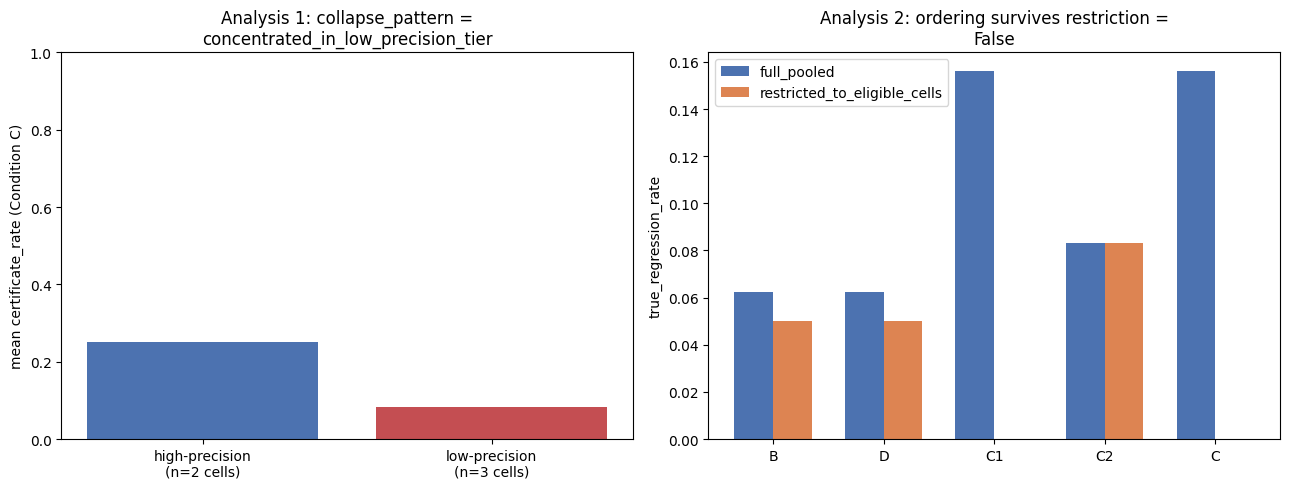

In [13]:
print("=" * 78)
print("SUMMARY (computed on the mini demo subset -- magnitudes will differ from")
print("the full-scale run, but the pipeline logic is identical)")
print("=" * 78)
for k, v in metrics_agg.items():
    print(f"{k:55s} {v}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# (a) certificate rate by precision tier
tiers = ["high_precision_tier", "low_precision_tier"]
tier_vals = [a1[t]["mean_certificate_rate"] or 0.0 for t in tiers]
tier_ns = [a1[t]["n_cells"] for t in tiers]
axes[0].bar([f"high-precision\n(n={tier_ns[0]} cells)", f"low-precision\n(n={tier_ns[1]} cells)"],
            tier_vals, color=["#4C72B0", "#C44E52"])
axes[0].set_ylabel("mean certificate_rate (Condition C)")
axes[0].set_title(f"Analysis 1: collapse_pattern =\n{a1['collapse_pattern']}")
axes[0].set_ylim(0, 1)

# (b) true_regression_rate by condition, full vs restricted
conditions = list(a2["comparison_table"].keys())
full_vals = [a2["comparison_table"][c]["full_pooled"]["true_regression_rate"] or 0.0 for c in conditions]
restr_vals = [a2["comparison_table"][c]["restricted_to_eligible_cells"]["true_regression_rate"] or 0.0 for c in conditions]
x = range(len(conditions))
width = 0.35
axes[1].bar([i - width / 2 for i in x], full_vals, width, label="full_pooled", color="#4C72B0")
axes[1].bar([i + width / 2 for i in x], restr_vals, width, label="restricted_to_eligible_cells", color="#DD8452")
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(conditions)
axes[1].set_ylabel("true_regression_rate")
axes[1].set_title(f"Analysis 2: ordering survives restriction =\n{a2['headline_ordering_survives_restriction']}")
axes[1].legend()

plt.tight_layout()
plt.show()